In [63]:
import numpy as np
import pandas as pd

sales = pd.read_csv('sales.csv')
customers = pd.read_csv('customers.csv')
products = pd.read_csv('products.csv')

print(f"sales: {sales.shape} (who bought what and when.)")
print(f"customers: {customers.shape} (customer details + region)")
print(f"products: {products.shape} (product details + price)")
print("\nSales table:")
sales.head()

sales: (1000, 5) (who bought what and when.)
customers: (52, 4) (customer details + region)
products: (20, 4) (product details + price)

Sales table:


,order_id,date,customer_id,product_id,quantity
0,O00001,2024-10-31,C999,P019,2
1,O00002,2024-03-14,C999,P014,1
2,O00003,2024-10-21,C999,P004,1
3,O00004,2024-01-03,C999,P003,3
4,O00005,2024-10-18,C999,P018,4


Part A — join the tables

TASK 01 

Build the master table

The curriculum's core join exercise. Combine three tables into one.

In [64]:
full = (
    sales
    .merge(customers, on="customer_id", how='left')
    .merge(products, on="product_id", how='left')
)

print("Master Table:")
print(full)


# Compute the revenue 
full['revenue'] = full['quantity'] * full['unit_price']
print("\n\nMaster Table with Revenue:")
print(full[['customer_id', 'product_id', 'quantity', 'unit_price', 'revenue']])

Master Table:
    order_id        date customer_id product_id  quantity customer_name  \
0     O00001  2024-10-31        C999       P019         2           NaN   
1     O00002  2024-03-14        C999       P014         1           NaN   
2     O00003  2024-10-21        C999       P004         1           NaN   
3     O00004  2024-01-03        C999       P003         3           NaN   
4     O00005  2024-10-18        C999       P018         4           NaN   
..       ...         ...         ...        ...       ...           ...   
995   O00996  2024-01-30        C039       P016         3   Customer_39   
996   O00997  2024-11-01        C047       P004         3   Customer_47   
997   O00998  2024-10-03        C044       P007         1   Customer_44   
998   O00999  2024-01-16        C038       P004         4   Customer_38   
999   O01000  2024-06-07        C013       P006         2   Customer_13   

    region  signup_year  product_name     category  unit_price  
0      NaN          

In [65]:
# Unknown customers
unknown_customers = sales.merge(customers, how='left', indicator=True)
unknown_customers = unknown_customers[unknown_customers['_merge'] == 'left_only']
unknown_customers.head(10)

,order_id,date,customer_id,product_id,quantity,customer_name,region,signup_year,_merge
0,O00001,2024-10-31,C999,P019,2,NaN,NaN,NaN,left_only
1,O00002,2024-03-14,C999,P014,1,NaN,NaN,NaN,left_only
2,O00003,2024-10-21,C999,P004,1,NaN,NaN,NaN,left_only
3,O00004,2024-01-03,C999,P003,3,NaN,NaN,NaN,left_only
4,O00005,2024-10-18,C999,P018,4,NaN,NaN,NaN,left_only


In [66]:
never_ordered = sales.merge(customers, how='right', indicator=True)
never_ordered = never_ordered[never_ordered['_merge'] == 'right_only']
len(never_ordered)

2

In [67]:
# Compare different joins
left_join = sales.merge(customers, on='customer_id', how='left')
inner_join = sales.merge(customers, on='customer_id', how='inner')
outer_join = sales.merge(customers, on='customer_id', how='outer', indicator=True)

print("\nSales rows :", len(sales))
print("Customer rows :", len(customers))
print("Inner join :", len(inner_join))
print("Left join :", len(left_join))
print("Outer join :", len(outer_join))


Sales rows : 1000
Customer rows : 52
Inner join : 995
Left join : 1000
Outer join : 1002


In [68]:
# Find mismatched
print("Join Status:")
print(outer_join["_merge"].value_counts())

Join Status:
_merge
both          995
left_only       5
right_only      2
Name: count, dtype: int64


Part B — per-region, per-month revenue (the deliverable core)

TASK 02 

Revenue breakdowns with groupby

The curriculum's per-region per-month activity. The heart of the deliverable.

In [69]:
# Total Revenue per region
revenue_by_region = full.groupby("region")['revenue'].sum()
print("Total Revenue per region")
print(revenue_by_region)

Total Revenue per region
region
East     121636
North     83444
South     81814
West     117271
Name: revenue, dtype: int64


In [70]:
# Total Revenue per cateogry and category drives the business
revenue_by_category = full.groupby("category")['revenue'].sum()
print("Total Revenue per cateogry")
print(revenue_by_category)
print("\nCategory driving the business")
print(revenue_by_category.idxmax())

Total Revenue per cateogry
category
Accessories     12081
Electronics    285690
Office         104000
Stationery       3379
Name: revenue, dtype: int64

Category driving the business
Electronics


In [71]:
# Use .agg() to compute, per category
category_summary = full.groupby("category").agg(
    total = ('revenue', 'sum'),
    avg = ('revenue', 'mean'),
    orders = ('order_id', 'count')
)

print("Category Summary:")
print(category_summary)

Category Summary:
              total         avg  orders
category                               
Accessories   12081   92.930769     130
Electronics  285690  466.813725     612
Office       104000  641.975309     162
Stationery     3379   35.197917      96


In [72]:
# Compute revenue per region per month
full['date'] = pd.to_datetime(full['date'])
full['month'] = full['date'].dt.month_name()

region_month_revenue = full.groupby(['region', 'month'])['revenue'].sum()
print("Revenue per region per month")
print(region_month_revenue)

Revenue per region per month
region  month    
East    April        10275
        August       12035
        December     14573
        February     11110
        January      11506
        July          9568
        June          6378
        March        13911
        May           5976
        November      5029
        October       8635
        September    12640
North   April         8534
        August        3604
        December      7609
        February     12119
        January       2975
        July          5573
        June          6915
        March         7269
        May          11601
        November      5831
        October       6562
        September     4852
South   April         3930
        August        6931
        December      6233
        February     12525
        January       6114
        July          5078
        June          3685
        March        10415
        May           6320
        November      6404
        October       6331
        

In [73]:
# Best and worst month for one region
north = region_month_revenue.loc['North']

best_month = north.idxmax()
best_revenue = north.max()

worst_month = north.idxmin()
worst_revenue = north.min()

print('North Region:')
print(f"Best Month : {best_month} -> {best_revenue}")
print(f"Worst Month : {worst_month} -> {worst_revenue}")

North Region:
Best Month : February -> 12119
Worst Month : January -> 2975


TASK 03 

Build a pivot table and a crosstab

The curriculum's pivot activity. Reshape your summaries into grids.

In [74]:
pivot_region_category = full.pivot_table(
    values='revenue',
    index='region',
    columns='category',
    aggfunc='sum',
    fill_value=0
)

print(pivot_region_category)

category  Accessories  Electronics  Office  Stationery
region                                                
East             3379        86260   31020         977
North            2231        56815   23420         978
South            3341        55530   22440         503
West             3110        86120   27120         921


In [75]:
pivot_region_month = full.pivot_table(
    values='revenue',
    index='region',
    columns='month',
    aggfunc='sum',
    fill_value=0
)

print(pivot_region_month)

month   April  August  December  February  January   July   June  March  \
region                                                                    
East    10275   12035     14573     11110    11506   9568   6378  13911   
North    8534    3604      7609     12119     2975   5573   6915   7269   
South    3930    6931      6233     12525     6114   5078   3685  10415   
West     5963    8677     10306     12241    11831  14303  14742   6993   

month     May  November  October  September  
region                                       
East     5976      5029     8635      12640  
North   11601      5831     6562       4852  
South    6320      6404     6331       7848  
West     3394     16039     8262       4520  


In [76]:
count = pd.crosstab(full['region'], full['category'])
print(count)

category  Accessories  Electronics  Office  Stationery
region                                                
East               33          156      45          26
North              26          143      38          22
South              32          114      36          19
West               38          195      43          29


Difference between revenue pivot and count that pivot table is about the total revenue of the region/category combination,
where count is about how many orders in region/category combination.

In [77]:
region, month = pivot_region_month.stack().idxmax()

print("Best Region:", region)
print("Best Month:", month)
print("Highest Revenue:", pivot_region_month.loc[region, month])

Best Region: West
Best Month: November
Highest Revenue: 16039


In [78]:
pivot_with_totals = full.pivot_table(
    values='revenue',
    index='region',
    columns='category',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='Total'
)

print("Pivot with totals:")
print(pivot_with_totals)

Pivot with totals:
category  Accessories  Electronics  Office  Stationery   Total
region                                                        
East             3379        86260   31020         977  121636
North            2231        56815   23420         978   83444
South            3341        55530   22440         503   81814
West             3110        86120   27120         921  117271
Total           12061       284725  104000        3379  404165


Part C — unlock the dates

TASK 04 

Day-of-week effects and monthly trends

The curriculum's date-processing and resampling activities.

In [79]:
# Date parse + month, day name, quarter
full['date'] = pd.to_datetime(full['date'])

full['month'] = full['date'].dt.month_name()
full['day_name'] = full['date'].dt.day_name()
full['quarter'] = full['date'].dt.quarter

print(full[['date', 'month', 'day_name', 'quarter']].head())

        date    month   day_name  quarter
0 2024-10-31  October   Thursday        4
1 2024-03-14    March   Thursday        1
2 2024-10-21  October     Monday        4
3 2024-01-03  January  Wednesday        1
4 2024-10-18  October     Friday        4


In [80]:
# Revenue by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thrusday', 'Friday', 'Saturday', 'Sunday']
by_day = full.groupby('day_name')['revenue'].sum().reindex(day_order)

print(by_day)
print("Busiest day:", by_day.idxmax())
print("Revenue:", by_day.max())

day_name
Monday       51266.0
Tuesday      61293.0
Wednesday    43207.0
Thrusday         NaN
Friday       56667.0
Saturday     50325.0
Sunday       75389.0
Name: revenue, dtype: float64
Busiest day: Sunday
Revenue: 75389.0


date
2024-01-31    32561
2024-02-29    47995
2024-03-31    38608
2024-04-30    28702
2024-05-31    27291
2024-06-30    31720
2024-07-31    34522
2024-08-31    31247
2024-09-30    29860
2024-10-31    30620
2024-11-30    33303
2024-12-31    38721
Freq: ME, Name: revenue, dtype: int64


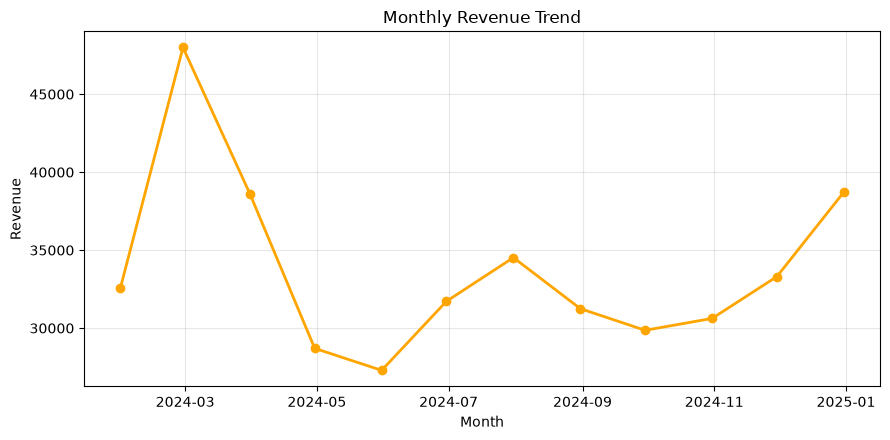

In [81]:
# Monthly total revenue
monthly = (
    full.set_index('date').resample('ME')['revenue'].sum()
)
print(monthly)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly.index, monthly.values, 'o-', color="orange", linewidth=2)
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

date
2024-01-07    10707
2024-01-14    13783
2024-01-21     4246
2024-01-28     2010
2024-02-04    16042
2024-02-11     7075
2024-02-18     8341
2024-02-25    11364
2024-03-03     9165
2024-03-10    10069
2024-03-17    12075
2024-03-24     2690
2024-03-31    11597
2024-04-07     3715
2024-04-14     7409
2024-04-21     8384
2024-04-28     6168
2024-05-05    12247
2024-05-12     1771
2024-05-19    12203
2024-05-26      801
2024-06-02     6715
2024-06-09     8867
2024-06-16     5530
2024-06-23     5684
2024-06-30     8219
2024-07-07     7220
2024-07-14    10638
2024-07-21     9017
2024-07-28     6306
2024-08-04     5870
2024-08-11     6679
2024-08-18     4196
2024-08-25     5609
2024-09-01    12520
2024-09-08     5980
2024-09-15     7768
2024-09-22     4559
2024-09-29     7882
2024-10-06     5163
2024-10-13     9534
2024-10-20    10115
2024-10-27     3341
2024-11-03    14957
2024-11-10     6453
2024-11-17     2840
2024-11-24     5705
2024-12-01     9370
2024-12-08    10856
2024-12-15     

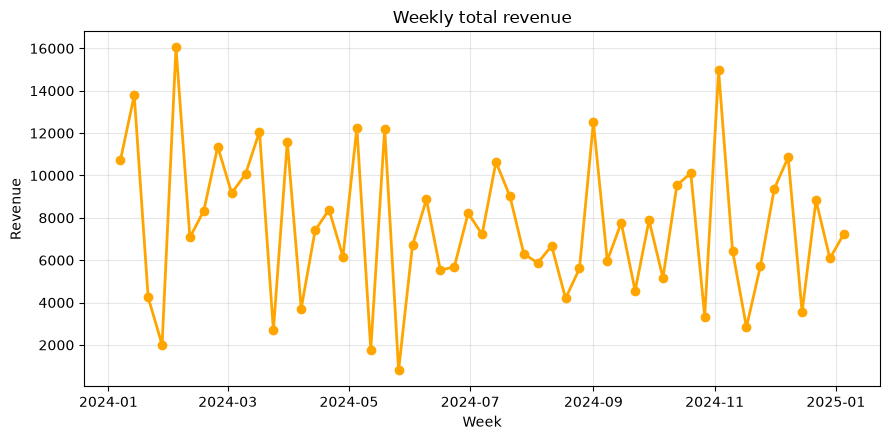

In [82]:
# Weekly Revenue
weekly = full.set_index('date').resample('W')['revenue'].sum()

print(weekly)
print("\nBusiest week:", weekly.idxmax())
print("weekly revenue:", weekly.max())

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(weekly.index, weekly.values, 'o-', color='orange', lw=2)
ax.set_title("Weekly total revenue")
ax.set_xlabel("Week")
ax.set_ylabel("Revenue")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Monthly → smoother, so the overall trend will be visible more clearly.

Weekly → more fluctuations/noise will be visible because revenue can vary from week to week.

In [83]:
# Peak month
peak_month = monthly.idxmax()
peak_revenue = monthly.max()

print("Peak Month:", peak_month)
print("Peak Revenue:", peak_revenue)

Peak Month: 2024-02-29 00:00:00
Peak Revenue: 47995


The busiest day of the week was 2024-02-04, which generated the highest total revenue [16042]. The monthly revenue peaked in 2024-02-29 (47995), and the monthly series shows the overall trend more clearly than the weekly series, which contains more fluctuations and noise.

TASK 05 

String operations

The curriculum's string-operations content. Clean and extract from text columns.

In [84]:
# Product name contains a particular word or letter.
products_with_a = products[
    products['product_name'].str.contains('a', case=False)
]

print("Products contain 'a':")
print(products_with_a)

Products contain 'a':
   product_id   product_name     category  unit_price
0        P001         Laptop  Electronics         800
2        P003       Keyboard  Electronics          45
4        P005         Webcam  Electronics          60
5        P006     Headphones  Electronics         120
7        P008      Desk Lamp       Office          40
8        P009          Chair       Office         180
9        P010  Standing Desk       Office         400
12       P013       Backpack  Accessories          55
13       P014   Water Bottle  Accessories          20
14       P015    Phone Stand  Accessories          18
15       P016      Cable Set  Electronics          30
16       P017     Power Bank  Electronics          50
17       P018        Speaker  Electronics          90
19       P020         Tablet  Electronics         350


In [85]:
# Category in uppercase
products['category_upper'] = products['category'].str.upper()

print(products['category_upper'])

0     ELECTRONICS
1     ELECTRONICS
2     ELECTRONICS
3     ELECTRONICS
4     ELECTRONICS
5     ELECTRONICS
6     ELECTRONICS
7          OFFICE
8          OFFICE
9          OFFICE
10     STATIONERY
11     STATIONERY
12    ACCESSORIES
13    ACCESSORIES
14    ACCESSORIES
15    ELECTRONICS
16    ELECTRONICS
17    ELECTRONICS
18    ELECTRONICS
19    ELECTRONICS
Name: category_upper, dtype: str


In [86]:
# Create product name length column
products['product_name_length'] = products['product_name'].str.len()

print(products['product_name_length'])

0      6
1      5
2      8
3      7
4      6
5     10
6      7
7      9
8      5
9     13
10     8
11     7
12     8
13    12
14    11
15     9
16    10
17     7
18    10
19     6
Name: product_name_length, dtype: int64


In [87]:
# Customers' IDs end in a particular digit 
end_with_4 = customers[customers['customer_id'].astype(str).str.endswith('4')]

print(end_with_4)

count = customers['customer_id'].astype(str).str.endswith('4').sum()
print("\nTotal count of end with 4:",count)

   customer_id customer_name region  signup_year
3         C004    Customer_4  South         2022
13        C014   Customer_14   West         2024
23        C024   Customer_24   West         2021
33        C034   Customer_34   East         2024
43        C044   Customer_44  South         2022

Total count of end with 4: 5


In [88]:
# start with a particular pattern
start_with_c00 = customers[customers['customer_id'].str.startswith('C00')]
count = len(start_with_c00)

print(start_with_c00)
print("\nTotal count of start with C00:",count)

  customer_id customer_name region  signup_year
0        C001    Customer_1  North         2024
1        C002    Customer_2   West         2021
2        C003    Customer_3   East         2022
3        C004    Customer_4  South         2022
4        C005    Customer_5  South         2022
5        C006    Customer_6   West         2021
6        C007    Customer_7  North         2023
7        C008    Customer_8   East         2021
8        C009    Customer_9  North         2023

Total count of start with C00: 9


In [92]:
# clean category text
products['category'] = (
    products['category'].str.strip().str.title()
)

print(products['category'])

0     Electronics
1     Electronics
2     Electronics
3     Electronics
4     Electronics
5     Electronics
6     Electronics
7          Office
8          Office
9          Office
10     Stationery
11     Stationery
12    Accessories
13    Accessories
14    Accessories
15    Electronics
16    Electronics
17    Electronics
18    Electronics
19    Electronics
Name: category, dtype: str


In [93]:
# Clean product name
products['product_name'] = (
    products['product_name'].str.strip().str.title()
)

print(products['product_name'])

0            Laptop
1             Mouse
2          Keyboard
3           Monitor
4            Webcam
5        Headphones
6           Usb Hub
7         Desk Lamp
8             Chair
9     Standing Desk
10         Notebook
11          Pen Set
12         Backpack
13     Water Bottle
14      Phone Stand
15        Cable Set
16       Power Bank
17          Speaker
18       Microphone
19           Tablet
Name: product_name, dtype: str
